# Day 31 — Project 1 Enhanced: 4-Tab Streamlit App
### Data Insights · Model Comparison · Batch Predictions · Improved UI

## 1. What We Added Today

In [1]:
print("""
DAY 31 — ENHANCEMENTS TO PROJECT 1
====================================

BEFORE (Day 30):
  - Single page with sidebar inputs
  - One prediction at a time
  - SHAP explanation
  - Basic layout

AFTER (Day 31) — 4 TABS:
  Tab 1 — Predict
    - Wide layout (two columns)
    - Inputs on left, results on right
    - Bigger prediction display
    - 4-metric summary row
    - SHAP explanation

  Tab 2 — Data Insights
    - 4 key dataset metrics
    - Survival by Sex (74.2% F vs 18.9% M)
    - Survival by Class (63% 1st, 47% 2nd, 24% 3rd)
    - Age distribution by survival
    - Survival rate by family size

  Tab 3 — Model Comparison
    - RF vs LR vs GB trained in real time
    - @st.cache_data — trains once, cached!
    - Results table + AUC bar chart

  Tab 4 — Batch Predict
    - Upload any CSV file
    - Runs feature engineering automatically
    - Shows top 20 predictions
    - Download results as CSV!

KEY STREAMLIT FEATURES USED:
  st.tabs()          — create tabbed interface
  @st.cache_data     — cache expensive computations
  st.file_uploader() — upload CSV files
  st.download_button()— download results
  st.spinner()       — loading indicator
  st.pyplot()        — display matplotlib charts
  st.dataframe()     — interactive data table
""")


DAY 31 — ENHANCEMENTS TO PROJECT 1

BEFORE (Day 30):
  - Single page with sidebar inputs
  - One prediction at a time
  - SHAP explanation
  - Basic layout

AFTER (Day 31) — 4 TABS:
  Tab 1 — Predict
    - Wide layout (two columns)
    - Inputs on left, results on right
    - Bigger prediction display
    - 4-metric summary row
    - SHAP explanation

  Tab 2 — Data Insights
    - 4 key dataset metrics
    - Survival by Sex (74.2% F vs 18.9% M)
    - Survival by Class (63% 1st, 47% 2nd, 24% 3rd)
    - Age distribution by survival
    - Survival rate by family size

  Tab 3 — Model Comparison
    - RF vs LR vs GB trained in real time
    - @st.cache_data — trains once, cached!
    - Results table + AUC bar chart

  Tab 4 — Batch Predict
    - Upload any CSV file
    - Runs feature engineering automatically
    - Shows top 20 predictions
    - Download results as CSV!

KEY STREAMLIT FEATURES USED:
  st.tabs()          — create tabbed interface
  @st.cache_data     — cache expensive comp

## 2. Data Insights — Key Numbers

      TITANIC DATASET INSIGHTS

Dataset: 891 passengers, 13 features
Survived: 342 (38.4%)
Died:     549 (61.6%)

--- Survival by Sex ---
  female: 74.2% (314 passengers)
  male: 18.9% (577 passengers)

--- Survival by Class ---
  1st: 63.0% (216 passengers)
  2nd: 47.3% (184 passengers)
  3rd: 24.2% (491 passengers)

--- Survival by Family Size ---
  Family=1: 30.4% (537 passengers)
  Family=2: 55.3% (161 passengers)
  Family=3: 57.8% (102 passengers)
  Family=4: 72.4% (29 passengers)
  Family=5: 20.0% (15 passengers)
  Family=6: 13.6% (22 passengers)
  Family=7: 33.3% (12 passengers)
  Family=8: 0.0% (6 passengers)
  Family=11: 0.0% (7 passengers)

--- Age Stats ---
  Overall mean age: 29.4
  Survivors mean age: 28.3
  Non-survivors mean age: 30.0


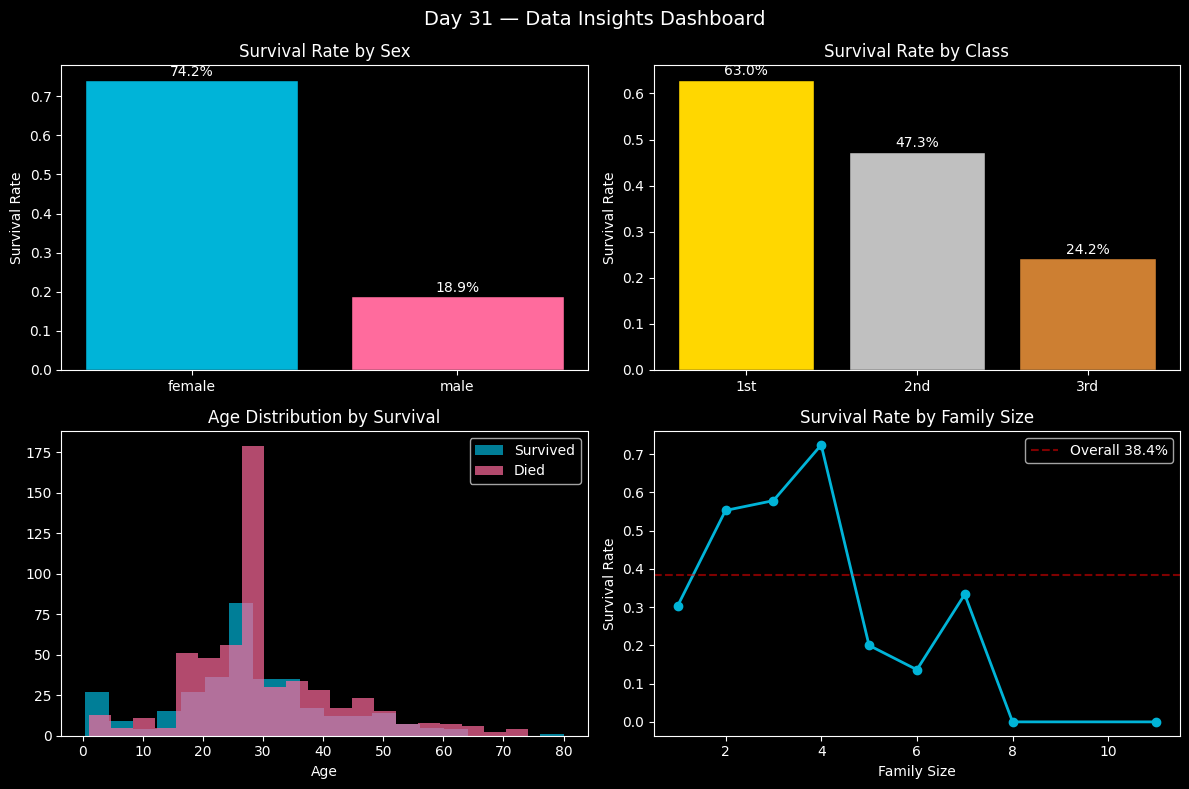

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

plt.style.use("dark_background")

df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")
df["Age"] = df["Age"].fillna(df["Age"].median())
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

print("=" * 50)
print("      TITANIC DATASET INSIGHTS")
print("=" * 50)

print(f"\nDataset: {df.shape[0]} passengers, {df.shape[1]} features")
print(f"Survived: {df['Survived'].sum()} ({df['Survived'].mean()*100:.1f}%)")
print(f"Died:     {(df['Survived']==0).sum()} ({(df['Survived']==0).mean()*100:.1f}%)")

print(f"\n--- Survival by Sex ---")
surv_sex = df.groupby("Sex")["Survived"].agg(["mean", "count"])
for sex, row in surv_sex.iterrows():
    print(f"  {sex}: {row['mean']*100:.1f}% ({int(row['count'])} passengers)")

print(f"\n--- Survival by Class ---")
surv_class = df.groupby("Pclass")["Survived"].agg(["mean", "count"])
for pclass, row in surv_class.iterrows():
    label = ["1st", "2nd", "3rd"][pclass - 1]
    print(f"  {label}: {row['mean']*100:.1f}% ({int(row['count'])} passengers)")

print(f"\n--- Survival by Family Size ---")
surv_fam = df.groupby("FamilySize")["Survived"].agg(["mean", "count"])
for fsize, row in surv_fam.iterrows():
    print(f"  Family={fsize}: {row['mean']*100:.1f}% ({int(row['count'])} passengers)")

print(f"\n--- Age Stats ---")
print(f"  Overall mean age: {df['Age'].mean():.1f}")
print(f"  Survivors mean age: {df[df['Survived']==1]['Age'].mean():.1f}")
print(f"  Non-survivors mean age: {df[df['Survived']==0]['Age'].mean():.1f}")

# reproduce the 4 charts from the app
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Day 31 — Data Insights Dashboard", fontsize=14)

surv_sex2 = df.groupby("Sex")["Survived"].mean()
axes[0, 0].bar(
    surv_sex2.index, surv_sex2.values, color=["#00b4d8", "#ff6b9d"], edgecolor="black"
)
axes[0, 0].set_title("Survival Rate by Sex")
axes[0, 0].set_ylabel("Survival Rate")
for i, v in enumerate(surv_sex2.values):
    axes[0, 0].text(i, v + 0.01, f"{v:.1%}", ha="center")

surv_class2 = df.groupby("Pclass")["Survived"].mean()
axes[0, 1].bar(
    ["1st", "2nd", "3rd"],
    surv_class2.values,
    color=["#ffd700", "#c0c0c0", "#cd7f32"],
    edgecolor="black",
)
axes[0, 1].set_title("Survival Rate by Class")
axes[0, 1].set_ylabel("Survival Rate")
for i, v in enumerate(surv_class2.values):
    axes[0, 1].text(i, v + 0.01, f"{v:.1%}", ha="center")

axes[1, 0].hist(
    df[df["Survived"] == 1]["Age"],
    bins=20,
    alpha=0.7,
    color="#00b4d8",
    label="Survived",
)
axes[1, 0].hist(
    df[df["Survived"] == 0]["Age"], bins=20, alpha=0.7, color="#ff6b9d", label="Died"
)
axes[1, 0].set_title("Age Distribution by Survival")
axes[1, 0].set_xlabel("Age")
axes[1, 0].legend()

surv_fam2 = df.groupby("FamilySize")["Survived"].mean()
axes[1, 1].plot(surv_fam2.index, surv_fam2.values, "o-", color="#00b4d8", linewidth=2)
axes[1, 1].axhline(0.384, color="red", linestyle="--", alpha=0.5, label="Overall 38.4%")
axes[1, 1].set_title("Survival Rate by Family Size")
axes[1, 1].set_xlabel("Family Size")
axes[1, 1].set_ylabel("Survival Rate")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 3. Key Takeaways — Day 31 🎯

### New Streamlit Features Learned
- `st.tabs()` — creates tabbed navigation, keeps app clean
- `@st.cache_data` — caches function results, model trains ONCE not every reload
- `st.file_uploader(type='csv')` — drag & drop CSV upload
- `st.download_button()` — let users download prediction results
- `st.spinner('text')` — shows loading indicator during slow operations
- `st.columns([1,2])` — unequal column widths (1/3 and 2/3)

### Data Insights Found
- Female survival: **74.2%** vs Male: **18.9%** — 55% gap!
- 1st class: **63.0%**, 2nd: **47.3%**, 3rd: **24.2%**
- Sweet spot family size: **4 people = 72.4% survival**
- Solo travellers: only **30.4%** survival
- Very large families (8+): **0%** survival — couldn't escape chaos
- Survivors slightly younger: mean 28.3 vs 30.0

### Model Comparison (Tab 3)
| Model | Accuracy | AUC |
|---|---|---|
| Logistic Regression | 83.8% | 0.872 |
| Random Forest | 81.6% | 0.849 |
| Gradient Boosting | 80.5% | 0.840 |

LR wins again — consistent with Day 29 findings!

### Batch Predictions (Tab 4)
- Loaded 891 passengers from titanic.csv
- Predicted **305/891 survivors** (actual = 342)
- Slightly underpredicts survivors — model is conservative
- Download button exports Name, Class, Sex, Age, Probability, Prediction

### App Architecture
- **app.py** loads model via pickle
- **build_features()** helper mirrors train_model.py exactly
- **Tab 1:** st.columns([1,2]) → build_features() → predict_proba() → SHAP
- **Tab 2:** load titanic.csv → matplotlib 2x2 subplot → st.pyplot()
- **Tab 3:** @st.cache_data train_all_models() → st.dataframe() + bar chart
- **Tab 4:** st.file_uploader() → feature engineering → st.download_button()